In [2]:
import scanpy as sc

/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import

In [3]:
import pandas as pd

In [3]:
adata_test_subset2 = sc.read('/home/bnvlab2/scVI_brain_organoids/organoids/neurons_scVI_scFates.h5ad')

In [3]:
meta_ES = pd.read_csv("/home/bnvlab2/scVI_brain_organoids/organoids/ES_brain_randall_pathways_age_subset.csv", index_col=0)
adata_test = sc.read('/home/bnvlab2/scVI_brain_organoids/organoids/randall_reemdedding_annotated.h5ad')
adata_test.obs.drop(columns=['cell_type_pred', 'cell_type_pred_upd', 'cell_type_uncert'], inplace=True)
meta = pd.read_csv("/home/bnvlab2/scVI_brain_organoids/organoids/celltype_predictions/meta_randall_celltype_pred3.csv", index_col=0)
#adata_test.obs = adata_test.obs.join(meta, how="left")
meta2 = pd.read_csv("/home/bnvlab2/scVI_brain_organoids/organoids/celltype_predictions/meta_randall4_7_V2.csv", index_col=0)
metadata_all = meta[['cell_type_pred3_upd']].join(meta2, how="left")
adata_test.obs = adata_test.obs.join(metadata_all, how="left")

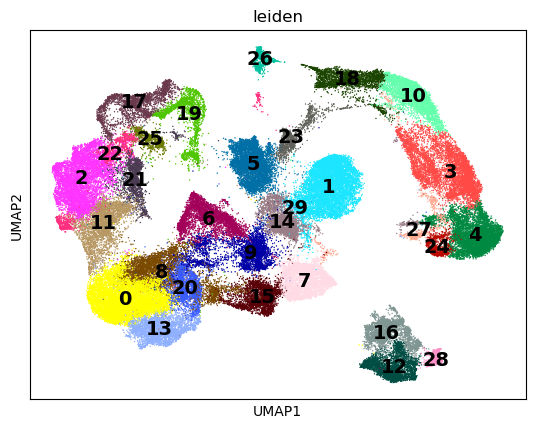

In [4]:
sc.pl.umap(adata_test, color = ['leiden'], use_raw = False, legend_loc = 'on data', size=4, legend_fontsize=14)

In [5]:
adata_test.obs['True_Condition'] = adata_test.obs['True_Condition'].astype('str').astype('category')
genotype_mapping = {
    '0': "ApoE3WT/PSEN1 E280A",
    '1': "ApoE3Ch/PSEN1 E280A",
    '2': "ApoE3WT/PSEN1WT",
    '3': "ApoE3Ch/PSEN1WT"
}
adata_test.obs["True_Condition2"] = adata_test.obs["True_Condition"].map(genotype_mapping)
genotype_mapping1 = {
    "ApoE3WT/PSEN1 E280A" : 'PSEN1 E280A',
    "ApoE3Ch/PSEN1 E280A" :'PSEN1 E280A',
    "ApoE3WT/PSEN1WT" : 'PSEN1WT',
    "ApoE3Ch/PSEN1WT" : 'PSEN1WT'
}
adata_test.obs["True_Condition_PSEN"] = adata_test.obs["True_Condition2"].map(genotype_mapping1)

In [6]:
adata_test

AnnData object with n_obs × n_vars = 89129 × 38606
    obs: 'nCount_RNA', 'nFeature_RNA', 'orig.ident', 'percent.rb', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'RNA_snn_res.1', 'seurat_clusters', 'pANN_0.25_0.19_1101', 'DF.classifications_0.25_0.19_1101', 'DF.classifications_0.25_0.19_1030', 'origin', 'condition', 'pANN_0.25_0.13_641', 'DF.classifications_0.25_0.13_641', 'DF.classifications_0.25_0.13_604', 'pANN_0.25_0.005_481', 'DF.classifications_0.25_0.005_481', 'DF.classifications_0.25_0.005_448', 'pANN_0.25_0.28_307', 'DF.classifications_0.25_0.28_307', 'DF.classifications_0.25_0.28_285', 'pANN_0.25_0.16_753', 'DF.classifications_0.25_0.16_753', 'DF.classifications_0.25_0.16_704', 'pANN_0.25_0.19_640', 'DF.classifications_0.25_0.19_640', 'DF.classifications_0.25_0.19_600', 'pANN_0.25_0.08_728', 'DF.classifications_0.25_0.08_728', 'DF.classifications_0.25_0.08_682', 'pANN_0.25_0.15_532', 'DF.classifications_0.25_0.15_532', 'DF.classifications_0.25_0.15_494', 'integrated_snn_re

In [7]:
import pandas as pd
import numpy as np

SCVI_LATENT_KEY = "X_scVI"  # same key you want in adata2

#Z = pd.read_parquet("/home/bnvlab2/scVI_brain_organoids/no_erythocytes_atlas/scripts/adata1_scvi_latent.parquet")
Z = pd.read_csv("/home/bnvlab2/scVI_brain_organoids/no_erythocytes_atlas/scripts/adata1_scvi_latent.csv", index_col=0)  # if you saved CSV

# Align by cell IDs
common = adata_test.obs_names.intersection(Z.index)
if len(common) == 0:
    raise ValueError("No overlapping cell IDs between adata2.obs_names and exported latent index.")

# Option A (strict): only assign to cells that have latent vectors
Z2 = Z.reindex(adata_test.obs_names)              # keeps full order of adata2
missing = Z2.isna().any(axis=1)
if missing.any():
    # drop rows with no latent (or handle as you wish)
    keep = ~missing
    adata_test = adata2[keep].copy()
    adata_test.obsm[SCVI_LATENT_KEY] = Z2.loc[keep].to_numpy()
    # (optional) overwrite adata2 with subset
    # adata2 = adata2_subset
else:
    adata_test.obsm[SCVI_LATENT_KEY] = Z2.to_numpy()


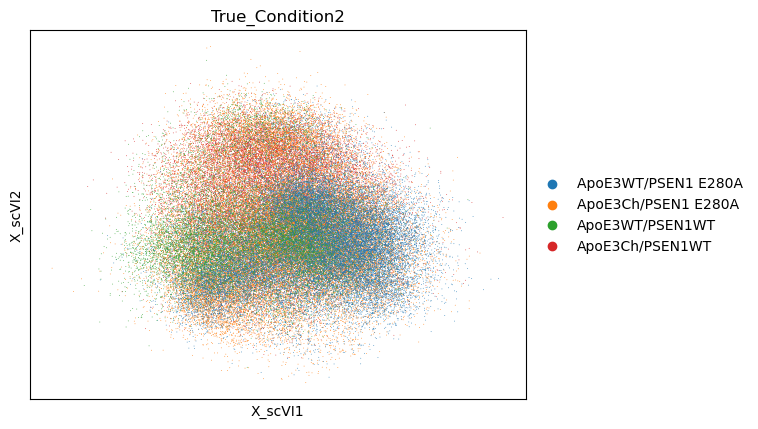

In [8]:
sc.pl.embedding(adata_test,color="True_Condition2",cmap="RdBu_r", basis='X_scVI' )


In [9]:
adata_test_subset = adata_test[adata_test.obs['cell_type_pred3_upd'].isin([  'Early Neurons',
                                                                           'Mature Neurons', 'IPC', 
           ])]   # 'NC derived neurons'
             # 'Glial Progenitors', 'Choroid Plexus', 'Neural crest', 'Mesenchyma',
                 # 'IPC'])]

In [10]:
adata_test_subset2 = adata_test_subset[~adata_test_subset.obs['leiden'].isin(['5', #'Ependymal', 
          ])]

/home/bnvlab2/miniconda3/lib/python3.12/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


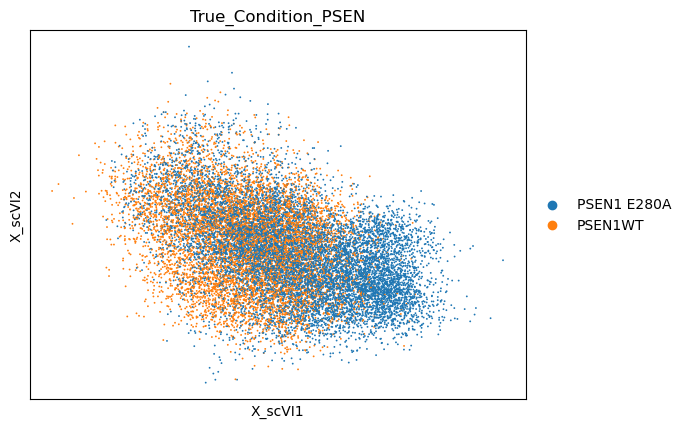

In [11]:
sc.pl.embedding(adata_test_subset2,color="True_Condition_PSEN",cmap="RdBu_r", basis='X_scVI' )


In [12]:
pca_projections = pd.DataFrame(adata_test_subset2.obsm["X_scVI"],index=adata_test_subset2.obs_names)

In [41]:
from anndata import AnnData
import numpy as np
import pandas as pd
import scanpy as sc
import scFates as scf
import palantir
import matplotlib.pyplot as plt
sc.settings.verbosity = 3
#sc.settings.logfile = sys.stdout

## fix palantir breaking down some plots
import seaborn

/home/bnvlab2/miniconda3/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "LD_LIBRARY_PATH" redefined by R and overriding existing variable. Current: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server", R: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server"
  warnings.warn(
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_LIBS_SITE" redefined by R and overriding existing variable. Current: "/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library:/usr/lib/R/site-library:/usr/lib/R/library", R: "/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library:/usr/lib/R/site-library:/usr/lib/R/library:/usr/lib/R/library:/usr/lib/R/library"
  warnings.warn(
/home/bnvlab2/mi

In [14]:
dm_res = palantir.utils.run_diffusion_maps(pca_projections)
ms_data = palantir.utils.determine_multiscale_space(dm_res, n_eigs=2) ## n_eigs 2-5 

computing neighbors


/home/bnvlab2/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-10-30 17:57:37.733718: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-30 17:57:37.858518: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761861457.905030  317501 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761861457.918998  317501 cuda_blas.cc:1407] Unabl

    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:19)


In [15]:
# generate neighbor draph in multiscale diffusion space
adata_test_subset2.obsm["X_palantir"]=ms_data.values
sc.pp.neighbors(adata_test_subset2,n_neighbors=30,use_rep="X_palantir")

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)


In [16]:
# draw ForceAtlas2 embedding using 2 first PCs as initial positions
adata_test_subset2.obsm["X_pca2d"]=adata_test_subset2.obsm["X_scVI"][:,:2]
sc.tl.draw_graph(adata_test_subset2,init_pos='X_pca2d')

drawing single-cell graph using layout 'fa'
    finished: added
    'X_draw_graph_fa', graph_drawing coordinates (adata.obsm) (0:00:44)


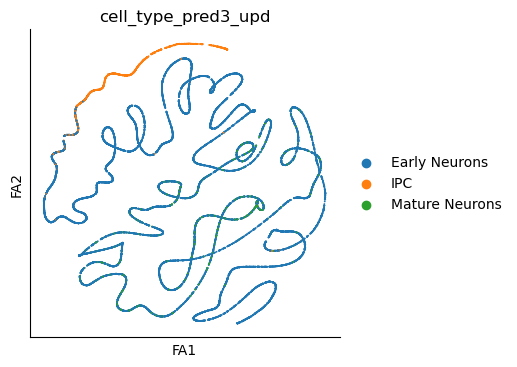

In [17]:
sc.pl.draw_graph(adata_test_subset2,color=["cell_type_pred3_upd"],color_map="RdBu_r")

In [39]:
import matplotlib.pyplot as plt
import scanpy as sc

# set default figure size (matplotlib)
plt.rcParams["figure.figsize"] = (5, 5)   # change as needed

# make plot and save (scanpy will save into sc.settings.figdir)
sc.settings.figdir = "./figures"          # change folder if you want
sc.pl.draw_graph(
    adata_test_subset2,
    color=["cell_type_pred3_upd"],
    color_map="RdBu_r",
    show=False,
    save="_cell_type_pred3_upd.pdf",      # filename suffix
)

plt.show()


In [38]:
import matplotlib.pyplot as plt
import scanpy as sc

# set default figure size (matplotlib)
plt.rcParams["figure.figsize"] = (5, 5)   # change as needed

# make plot and save (scanpy will save into sc.settings.figdir)
sc.settings.figdir = "./figures"          # change folder if you want
sc.pl.draw_graph(
    adata_test_subset2,
    color=["True_Condition_PSEN"],
    color_map="RdBu_r",
    show=False,
    save="_True_Condition_PSEN.pdf",      # filename suffix
)

plt.show()


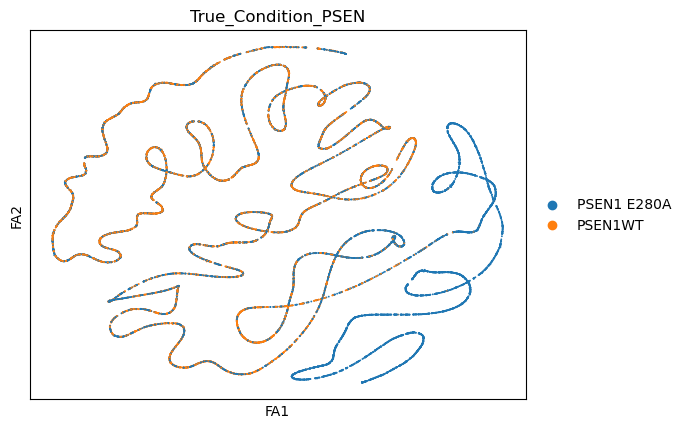

In [35]:
sc.pl.draw_graph(adata_test_subset2,color=["True_Condition_PSEN"],color_map="RdBu_r")

In [1]:
sc.pl.draw_graph(adata_test_subset2,color=["True_Condition_PSEN"],color_map="RdBu_r")

NameError: name 'sc' is not defined

In [19]:
scf.tl.tree(adata_test_subset2,method="ppt",
            Nodes=220, ##50
            use_rep="palantir",
            device="cpu",seed=1,
            ppt_lambda=50, ppt_sigma=0.0019, ### ppt_lambda ppt_sigma 0.125
            ppt_nsteps=200 #50
           )


inferring a principal tree --> parameters used 
    220 principal points, sigma = 0.0019, lambda = 50, metric = euclidean
    fitting:  26%|███████▌                     | 52/200 [00:02<00:05, 25.68it/s]
    converged
    finished (0:00:02) --> added 
    .uns['ppt'], dictionnary containing inferred tree.
    .obsm['X_R'] soft assignment of cells to principal points.
    .uns['graph']['B'] adjacency matrix of the principal points.
    .uns['graph']['F'] coordinates of principal points in representation space.


/home/bnvlab2/miniconda3/lib/python3.12/site-packages/simpleppt/utils.py:58: RuntimeWarning: invalid value encountered in divide
  res = (B1.T.dot(A1)).T / np.sqrt(
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/simpleppt/ppt.py:267: RuntimeWarning: divide by zero encountered in log
  sigma / R.shape[0] * np.sum(R * np.log(R)),
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/simpleppt/ppt.py:267: RuntimeWarning: invalid value encountered in multiply
  sigma / R.shape[0] * np.sum(R * np.log(R)),


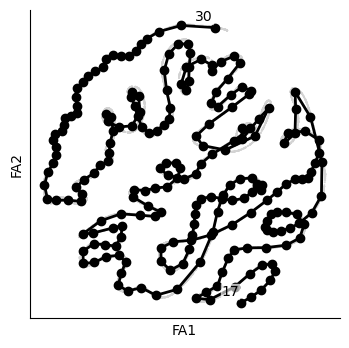

In [20]:
scf.pl.graph(adata_test_subset2)

In [21]:
import gc
gc.collect()

17194

In [22]:
scf.tl.root(adata_test_subset2,30)

node 30 selected as a root --> added
    .uns['graph']['root'] selected root.
    .uns['graph']['pp_info'] for each PP, its distance vs root and segment assignment.
    .uns['graph']['pp_seg'] segments network information.


In [23]:
scf.tl.pseudotime(adata_test_subset2,n_jobs=2,n_map=50,seed=42)

projecting cells onto the principal graph
    mappings:   0%|                                      | 0/50 [00:00<?, ?it/s]

/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import

    mappings: 100%|█████████████████████████████| 50/50 [11:37<00:00, 13.95s/it]
    finished (0:11:39) --> added
    .obs['edge'] assigned edge.
    .obs['t'] pseudotime value.
    .obs['seg'] segment of the tree assigned.
    .obs['milestones'] milestone assigned.
    .uns['pseudotime_list'] list of cell projection from all mappings.


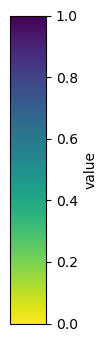

In [48]:
import matplotlib.pyplot as plt
import matplotlib as mpl

outdir = "./figures"
fname = "viridis_cbar.pdf"

fig, ax = plt.subplots(figsize=(1.2, 4))  # skinny colorbar
fig.subplots_adjust(left=0.5, right=0.8)  # leave room for labels

norm = mpl.colors.Normalize(vmin=0, vmax=1)  # change to your range if needed
cbar = fig.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap="viridis_r"),
    cax=ax,
)
cbar.set_label("value")  # optional

fig.savefig(f"{outdir}/{fname}", dpi=300, bbox_inches="tight")
plt.show()


In [42]:
import os
import matplotlib.pyplot as plt

# make sure output dir exists
outdir = "./figures"
os.makedirs(outdir, exist_ok=True)

plt.rcParams["figure.figsize"] = (5, 5)

# scFates trajectory plot
fig, ax = plt.subplots()
scf.pl.trajectory(adata_test_subset2, ax=ax, show=False)

fig.savefig(os.path.join(outdir, "trajectory.pdf"), dpi=300, bbox_inches="tight")
plt.close(fig)


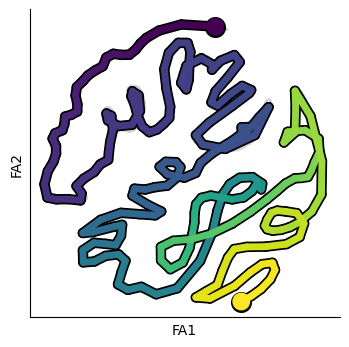

In [25]:
scf.pl.trajectory(adata_test_subset2)

In [198]:
import scvelo as scv

In [199]:
neuralization_top50 = [
    # cluster 0
    "NEUROD1","NEUROD4","NEUROG1","ASCL1","SATB2","SLC17A6","RELN","KCNC2","TCF4","CLSTN2",
    # cluster 1
    "SNAP25","DLG2","SHANK2","NRXN2","NRXN3","NTRK2","RIMS1","PCLO","CACNA1C","SCN2A",
    # cluster 2
    "DCX","STMN2","GAP43","NEFL","NRN1","SYT1","VAMP2","MAPT","GPM6A","DPYSL2",
    # cluster 3
    "NEUROD6","MEF2C","NR2F1","LHX2","FOXP2","CALB1","NLGN1","CNTN2","RBFOX1","KCNQ3",
    # cluster 4 (keep neuron-leaning only)
    "TUBB4B","ENO2",
    # cluster 5 (drop APP to stay neuro-maturation focused)
    "NRXN1","RIMS2","PTPRD","CNTNAP2","NCAM1","DCC","EPHA6","KALRN",
    # cluster 6
    "ELAVL3","NSG1","NSG2","SCG2","CNIH2","TMEM59L","FEZ1","KIF21A","DNER"
]


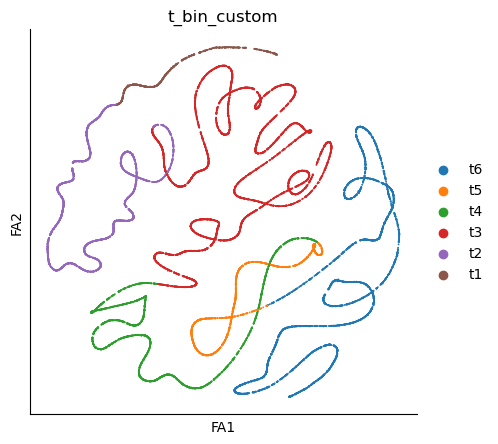

In [207]:
sc.pl.draw_graph(adata_test_subset2,color=["t_bin_custom"],color_map="RdBu_r")

saving figure to file ./figures/scvelo_heatmap_neuralization_scVelo_pheatmap_scVI.pdf


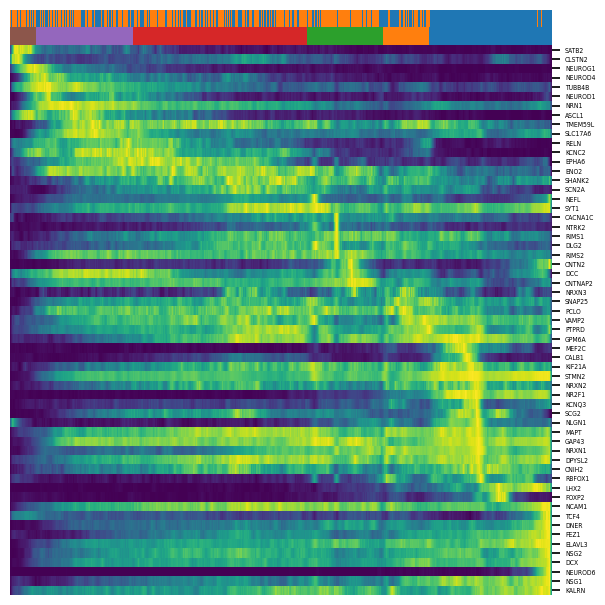

In [210]:
scv.pl.heatmap(adata_test_subset2, var_names=neuralization_top50,
               sortby='t', col_color=['True_Condition_PSEN', 't_bin_custom'], font_scale = 0.4,
               n_convolve=150, figsize=(6, 6),  save='neuralization_scVelo_pheatmap_scVI.pdf')

In [214]:
df1 = adata_test_subset2.obs[['t', 't_bin_custom']]

In [215]:
import pandas as pd

df = adata_test_subset2.obs[['t', 't_bin_custom']].copy()
df['t'] = pd.to_numeric(df['t'], errors='coerce')  # in case it's string

t_ranges = (df
    .dropna(subset=['t', 't_bin_custom'])
    .groupby('t_bin_custom')['t']
    .agg(n='size', t_min='min', t_max='max')
    .sort_values('t_min')
)

t_ranges


,n,t_min,t_max
t_bin_custom,,,
t1,831,9.501177e-07,0.199821
t2,3094,2.001610e-01,0.499970
t3,5540,5.000254e-01,0.999573
t4,2452,1.001765e+00,1.497456
t5,1447,1.502247e+00,2.196812
t6,3932,2.202132e+00,2.998862


In [26]:
d={ 'IPC': ['EOMES',
  'ASCL1',
  'NEUROG1',
  'NEUROG2',
  'NEUROD1',
  'NEUROD2',
  'NEUROD4',
  'NHLH1',
  'HES6',
  'PPP1R17'],
 'Postmitotic / Immature Neurons': ['TBR1',
  'ELAVL3',
  'ELAVL4',
  'DCX',
  'TUBB3',
  'NEUROD6',
  'STMN2'],
 'Mature Neurons': ['SATB2',
  'BCL11B',
  'RBFOX3',
  'SNAP25',
  'SYT1',
  'MYT1L',
  'MEF2C',
  'GRIN2B',
  'CADM2',
  'RIMS2',
  'NRXN1',
  'SLC17A7']}


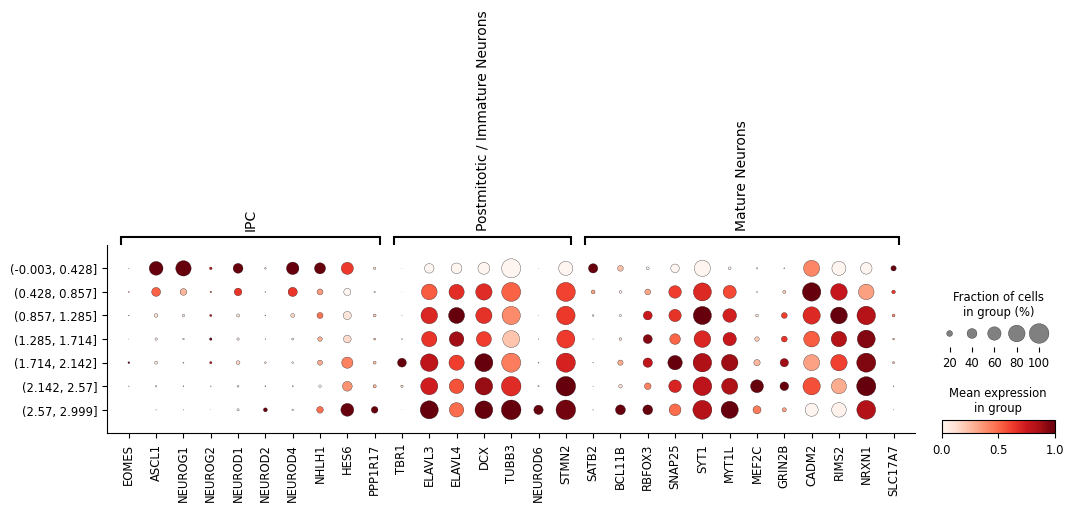

In [27]:
 sc.pl.dotplot(
    adata_test_subset2,
    var_names=d, #NC_neuron,
   # expression_cutoff=1.5,
    groupby=['t'],# 'True_Condition_PSEN'],  # or 'leiden', etc.
    use_raw=True,         # or False if you're working with normalized data
    standard_scale='var', # normalize gene-wise (optional)
  # save='wnt_atlas_dotplot_general.png',
  # dendrogram=True       # optional clustering of groups
)

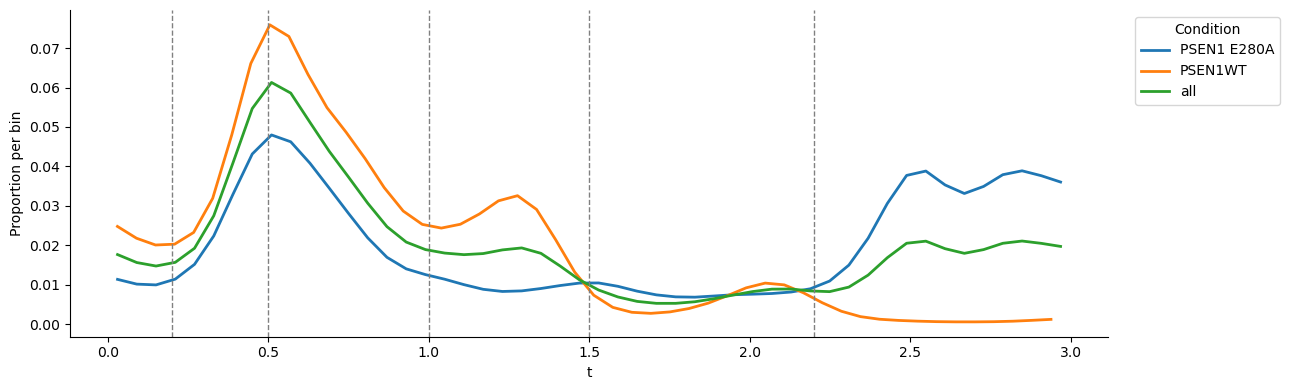

In [209]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data
df = adata_test_subset2.obs[['t', 'True_Condition_PSEN']].copy()
df['t'] = pd.to_numeric(df['t'], errors='coerce')
df = df.dropna(subset=['t'])

df_all = df.copy()
df_all['True_Condition_PSEN'] = 'all'

df = pd.concat([df, df_all], ignore_index=True)

# Smoothing helpers
try:
    from scipy.ndimage import gaussian_filter1d
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False

def smooth_proportions(y, gaussian_sigma=1.5, ma_window=7):
    if _HAS_SCIPY:
        return gaussian_filter1d(y.astype(float), sigma=gaussian_sigma, mode='nearest')
    # fallback: Hann moving average
    w = max(3, int(ma_window) | 1)  # force odd, >=3
    kernel = np.hanning(w)
    kernel /= kernel.sum()
    return np.convolve(y.astype(float), kernel, mode='same')

# Binning + plotting
bins = 50        # tweak for resolution
gauss_sigma = 1.5  # increase for smoother; decrease for sharper
ma_window = 7      # used only if SciPy is unavailable

fig, ax = plt.subplots(figsize=(13, 4))

for cond, sub in df.groupby('True_Condition_PSEN'):
    x = sub['t'].values
    counts, edges = np.histogram(x, bins=bins, density=False)
    total = counts.sum()
    probs = counts / total if total > 0 else counts
    centers = 0.5 * (edges[1:] + edges[:-1])

    probs_smooth = smooth_proportions(probs, gaussian_sigma=gauss_sigma, ma_window=ma_window)
    # re-normalize to keep area ≈ 1 across bins after smoothing (optional)
    area = probs_smooth.sum()
    if area > 0:
        probs_smooth = probs_smooth / area

    ax.plot(centers, probs_smooth, linewidth=2, label=str(cond))

ax.set_xlabel("t")
ax.set_ylabel("Proportion per bin")
ax.legend(title="Condition", loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.subplots_adjust(right=0.78)

vlines = [0.2, 0.5, 1, 1.5, 2.2,]

#vlines = [0.667, 1.334, 2.001, 4.67, 4.003, 2.668, 3.336]

#vlines = [0.4, 1.13, 1.85, 4.67,   3.2, 3.8] -- how it was


for xv in vlines:
    ax.axvline(x=xv, color='gray', linestyle='--', linewidth=1)


plt.tight_layout()

out_png = "per_condition_hist_smoothed_all_scVI.png"
out_pdf = "per_condition_hist_smoothed_all_scVI.pdf"
plt.tight_layout()
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
plt.show()



In [155]:
	n	t_min	t_max
t_bin_custom			
t1	831	9.501177e-07	0.199821
t2	3094	2.001610e-01	0.499970
t3	5540	5.000254e-01	0.999573
t4	2452	1.001765e+00	1.497456
t5	1447	1.502247e+00	2.196812
t6	3932	2.202132e+00	2.998862


Variable                       Type                    Data/Info
----------------------------------------------------------------
AnnData                        DeprecationMixinMeta    <class 'anndata._core.anndata.AnnData'>
SCVI_LATENT_KEY                str                     X_scVI
Z                              DataFrame                                       s<...>[89129 rows x 20 columns]
Z2                             DataFrame                                       s<...>[89129 rows x 20 columns]
adata                          AnnData                 AnnData object with n_obs<...>nectivities', 'distances'
adata_test                     AnnData                 AnnData object with n_obs<...> obsm: 'X_umap', 'X_scVI'
adata_test_subset              AnnData                 View of AnnData object wi<...> obsm: 'X_umap', 'X_scVI'
adata_test_subset2             AnnData                 AnnData object with n_obs<...>tances', 'connectivities'
area                           float64         

In [178]:
df = adata_test_subset2.obs[['t_bin_custom', 'cell_type_pred3_upd']].copy()
ct = (
    df
    .groupby(['t_bin_custom', 'cell_type_pred3_upd'])
    .size()
    .unstack(fill_value=0)
)

# optional: sort bins if needed
ct = ct.sort_index()

ct = ct.div(ct.sum(axis=1), axis=0)

/tmp/ipykernel_10478/3935243022.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['t_bin_custom', 'cell_type_pred3_upd'])


In [179]:
ct = ct.div(ct.sum(axis=1), axis=0)

In [180]:
gc.collect()

30758

In [184]:
ct = ct.iloc[::-1]

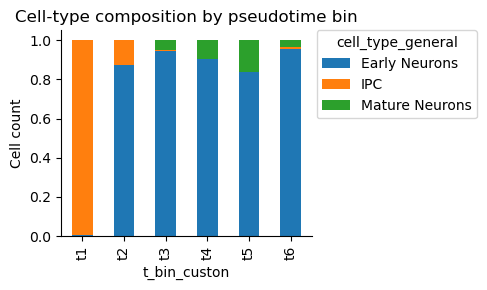

In [186]:
ax = ct.plot(
    kind='bar',
    stacked=True,
    figsize=(5, 3),
   # legend=False
   # color=[palette_cell_types.get(c, '#999999') for c in ct.columns]
)

ax.set_xlabel('t_bin_custon')
ax.set_ylabel('Cell count')
ax.set_title('Cell-type composition by pseudotime bin')
ax.legend(
    title='cell_type_general',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0.
)
plt.tight_layout()

out = "randall_composition_by_pseudotime_bin.pdf"
ax.figure.savefig(out, dpi=300, bbox_inches="tight")  # bbox_inches keeps the legend

plt.show()

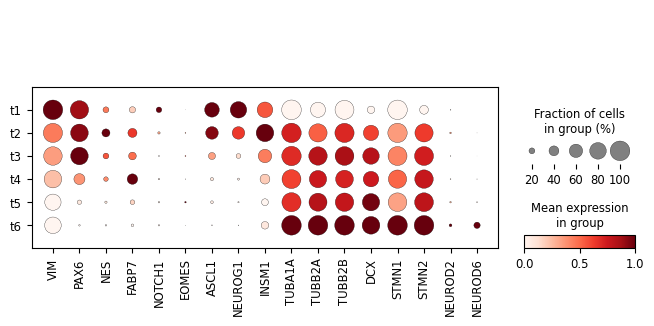

In [8]:
 sc.pl.dotplot(
    adata_test_subset2,
    var_names=['VIM',  'PAX6','NES','FABP7','NOTCH1', 
               'EOMES','ASCL1','NEUROG1','INSM1', 'TUBA1A', 'TUBB2A', 'TUBB2B', 'DCX', 'STMN1', 'STMN2',
              'NEUROD2', 'NEUROD6',], #NC_neuron,
   # expression_cutoff=1.5,
    groupby=['t_bin_custom'],# 'True_Condition_PSEN'],  # or 'leiden', etc.
    use_raw=True,         # or False if you're working with normalized data
    standard_scale='var', # normalize gene-wise (optional)
    save='early_maturation_markers.pdf',
  # dendrogram=True       # optional clustering of groups
)

In [84]:
adata = sc.read("/home/bnvlab2/scVI_brain_organoids/organoids/nerons_embedding_all_pathways.h5ad")

In [85]:
adata.obs['t'] = adata_test_subset2.obs['t'].copy()

In [86]:
adata.obs['t_bin_custom'] = adata_test_subset2.obs['t_bin_custom'].copy()

In [175]:
go_pathways_top30 = [

        # Proteostasis & translation (non-mito)
    "GOBP_PROTEIN_FOLDING",
    "GOBP_RIBOSOME_BIOGENESIS",
   # "GOBP_RNA_SPLICING",
    "GOBP_PROTEASOMAL_PROTEIN_CATABOLIC_PROCESS",
    #"GOBP_RESPONSE_TO_ENDOPLASMIC_RETICULUM_STRESS",

    # Chromatin & transcriptional phosphorylation
    "GOBP_CHROMATIN_ORGANIZATION",
    "GOBP_HISTONE_PHOSPHORYLATION",



    "GOBP_OXIDATIVE_PHOSPHORYLATION",
    "GOBP_MITOCHONDRIAL_ELECTRON_TRANSPORT_NADH_TO_UBIQUINONE",
    #"GOBP_MITOCHONDRIAL_ELECTRON_TRANSPORT_UBIQUINOL_TO_CYTOCHROME_C",
    #"GOBP_MITOCHONDRIAL_ELECTRON_TRANSPORT_CYTOCHROME_C_TO_OXYGEN",
    "GOBP_MITOCHONDRIAL_ATP_SYNTHESIS_COUPLED_PROTON_TRANSPORT",
    "GOBP_MITOCHONDRIAL_RESPIRATORY_CHAIN_COMPLEX_ASSEMBLY",
    "GOBP_MITOCHONDRIAL_RESPIRASOME_ASSEMBLY",
   # "GOBP_MITOCHONDRIAL_TRANSLATION",
    "GOBP_PROTEIN_IMPORT_INTO_MITOCHONDRIAL_MATRIX",
    #"GOBP_MITOCHONDRIAL_CALCIUM_ION_HOMEOSTASIS",



     "GOBP_APOPTOTIC_SIGNALING_PATHWAY",
    #"GOBP_APOPTOTIC_CELL_CLEARANCE",
    # "GOBP_APOPTOTIC_CHROMOSOME_CONDENSATION",
     "GOBP_APOPTOTIC_DNA_FRAGMENTATION",
     "GOBP_APOPTOTIC_MITOCHONDRIAL_CHANGES",
    #"GOBP_APOPTOTIC_PROCESS_INVOLVED_IN_DEVELOPMENT",
    "GOBP_NEURON_APOPTOTIC_PROCESS",

    
    
    # Neurogenesis → maturation
    "GOBP_NEUROGENESIS",
    "GOBP_NEURON_DEVELOPMENT",
   # "GOBP_CENTRAL_NERVOUS_SYSTEM_NEURON_DEVELOPMENT",
    "GOBP_NEURON_DIFFERENTIATION",
    #"GOBP_CENTRAL_NERVOUS_SYSTEM_NEURON_DIFFERENTIATION",
    "GOBP_NEURON_MATURATION",
    "GOBP_CELL_MORPHOGENESIS_INVOLVED_IN_NEURON_DIFFERENTIATION",

    # Axon & dendrite morphogenesis (with regulation)
    "GOBP_AXON_DEVELOPMENT",
    "GOBP_AXON_EXTENSION",
    "GOBP_REGULATION_OF_AXONOGENESIS",
    "GOBP_DENDRITE_DEVELOPMENT",
    "GOBP_DENDRITE_MORPHOGENESIS",
#    "GOBP_REGULATION_OF_DENDRITE_DEVELOPMENT",
    "GOBP_NEURON_MIGRATION",

    # Synapse assembly → transmission → regulation
    "GOBP_SYNAPSE_ORGANIZATION",
    "GOBP_PRESYNAPTIC_ACTIVE_ZONE_ORGANIZATION",
    #"GOBP_POSTSYNAPTIC_MEMBRANE_ORGANIZATION",
    "GOBP_POSTSYNAPTIC_SIGNAL_TRANSDUCTION",
   # "GOBP_TRANS_SYNAPTIC_SIGNALING_BY_TRANS_SYNAPTIC_COMPLEX",
    "GOBP_REGULATION_OF_SYNAPSE_STRUCTURE_OR_ACTIVITY",
   # "GOBP_REGULATION_OF_POSTSYNAPTIC_CYTOSOLIC_CALCIUM_ION_CONCENTRATION",

   
]


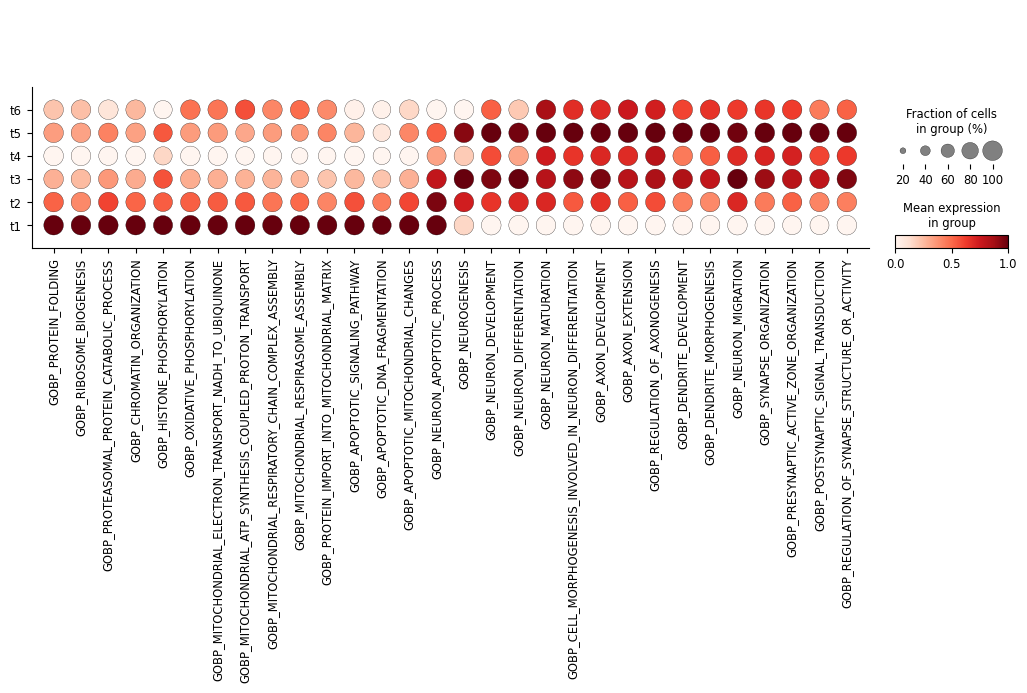

In [177]:
sc.pl.dotplot(
    adata,
    var_names=go_pathways_top30, #NC_neuron,
   # expression_cutoff=1.5,
    groupby=[  't_bin_custom' ], #, 'True_Condition_PSEN' ],  # or 'leiden', etc.
    use_raw=True,         # or False if you're working with normalized data
    standard_scale='var', # normalize gene-wise (optional)
    save='randall_go_pathways_filtered.pdf',
  # dendrogram=True       # optional clustering of groups
)

In [104]:
wnt_bmp_nothch_pathways = ['GOBP_CANONICAL_WNT_SIGNALING_PATHWAY',
 'GOBP_NON_CANONICAL_WNT_SIGNALING_PATHWAY',
 'GOBP_REGULATION_OF_WNT_SIGNALING_PATHWAY',
 'GOBP_POSITIVE_REGULATION_OF_WNT_SIGNALING_PATHWAY',
 'GOBP_NEGATIVE_REGULATION_OF_WNT_SIGNALING_PATHWAY',
 'GOBP_REGULATION_OF_CANONICAL_WNT_SIGNALING_PATHWAY',
 'GOBP_POSITIVE_REGULATION_OF_CANONICAL_WNT_SIGNALING_PATHWAY',
 'GOBP_NEGATIVE_REGULATION_OF_CANONICAL_WNT_SIGNALING_PATHWAY',
 'GOBP_REGULATION_OF_NON_CANONICAL_WNT_SIGNALING_PATHWAY',
 'GOBP_POSITIVE_REGULATION_OF_NON_CANONICAL_WNT_SIGNALING_PATHWAY',
 'GOBP_RESPONSE_TO_BMP',
 'GOBP_REGULATION_OF_BMP_SIGNALING_PATHWAY',
 'GOBP_POSITIVE_REGULATION_OF_BMP_SIGNALING_PATHWAY',
 'GOBP_NEGATIVE_REGULATION_OF_BMP_SIGNALING_PATHWAY',
 'GOBP_REGULATION_OF_NOTCH_SIGNALING_PATHWAY',
 'GOBP_POSITIVE_REGULATION_OF_TRANSCRIPTION_OF_NOTCH_RECEPTOR_TARGET']

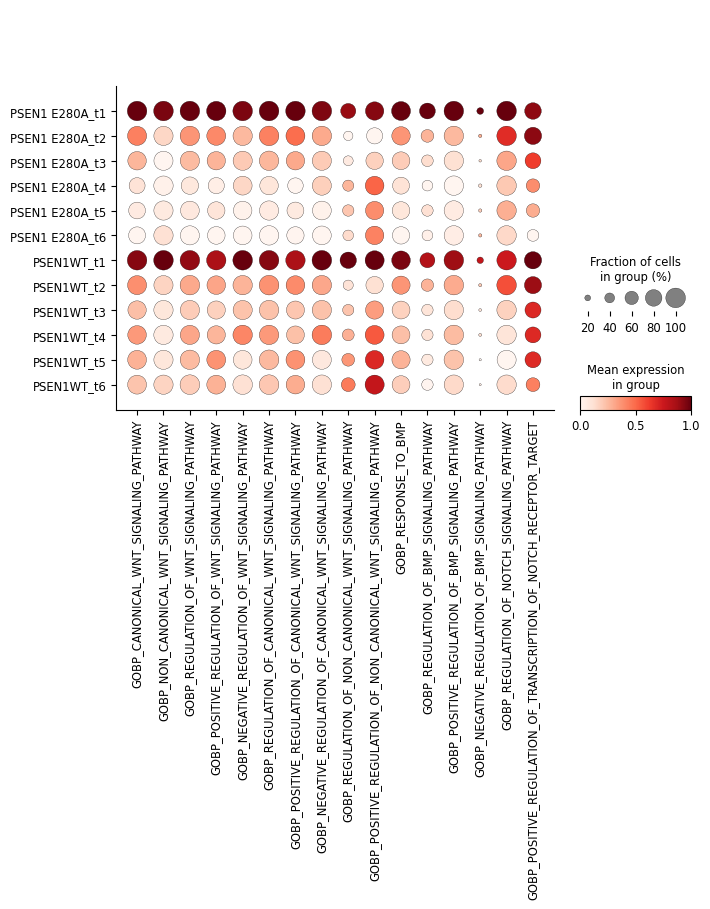

In [154]:
sc.pl.dotplot(
    adata,
    var_names=wnt_bmp_nothch_pathways, #NC_neuron,
   # expression_cutoff=1.5,
    groupby=[ 'True_Condition_PSEN' ,  't_bin_custom' ],  # or 'leiden', etc.
    use_raw=True,         # or False if you're working with normalized data
    standard_scale='var', # normalize gene-wise (optional)
   # save='atlas_neuralization.png',
  # dendrogram=True       # optional clustering of groups
)